In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import Galactic, ICRS, SkyCoord, GalacticLSR
from astropy import units as u
from modules.velocity_transformations import equatorial_UVW
from modules.vr_opt import VrOpt
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import normalized_mutual_info_score
from sklearn.cluster import KMeans
#from sklearn.neighbors import kneighbors_graph, sort_graph_by_row_values

from Distant_SigMA.SigMA.SigMA import SigMA
from astropy.table import Table
from pyia import GaiaData
from scipy.stats import gaussian_kde
import plotting_ftcs_tree
import itertools
from TreeSigMA import TreeSigMAWithHierarchy  
import os
import plotly.express as px
import tree_related_ftcs
import coord_transformation
import nbimporter
import shell_grid

In [246]:
# Plotting related stuff
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

In [248]:
#load data set 
tbl = Table.read('50pc_gaiaDR3_parallax_over_error5_sigmax.csv') #LocalBox_DR3_parallax_over_error10_sigmamax, 50pc_gaiaDR3_parallax_over_error5_sigmax, 100pc_gaiaDR3_parallax_over_error5_sigmamax.csv
g=GaiaData(tbl)

In [249]:
df = g.data.to_pandas()
c, gal, pos_hel, vel_hel, gal_lsr, vel_lsr =coord_transformation.coord_transformation_single(g['ra'].value,g['dec'].value ,(1/g['parallax'].value)*1000,g['pmra'].value,g['pmdec'].value,g['radial_velocity'].value)

In [250]:
df['x'] = pos_hel[0]
df['y'] = pos_hel[1]
df['z'] = pos_hel[2]
df['u'] = vel_hel[0]
df['v'] = vel_hel[1]
df['w'] = vel_hel[2]

df['dist'] = (1/df.parallax)*1000
df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74
#df.to_csv("50pcGaia.csv", index=False)

Text(0, 0.5, 'y')

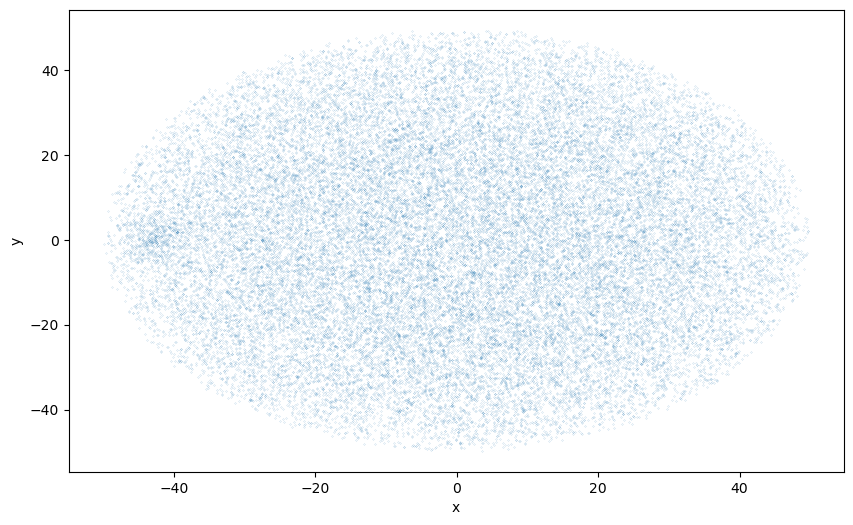

In [254]:
x_col, y_col = 'x', 'y'
#x_col, y_col = 'vx', 'vy'
#x_col, y_col = 'vt_ra', 'vt_dec'
#x_col, y_col = 'pmra', 'pmdec'
plt.figure(figsize=(10, 6))  
plt.scatter(df[x_col], df[y_col], s=0.01, alpha=0.9, zorder=2)
plt.xlabel(x_col)
plt.ylabel(y_col)

# Combine with df from Gagne

In [257]:
df_gagne = pd.read_csv('Table5and7_YLAs_GaiaDR3.csv')

In [259]:
#Add labels column for certain clusters dict = {1: 'BPMG', 2: 'CAR',   3: 'ABDMG',   4: 'XFOR',   5: 'THA',   6: 'TWA',   7: 'COL',  8: 'ETAC', 9: 'THOR', 10: 'EPSC', 11: '118TAU', 12:'OCT'}
df = df.merge(df_gagne[['source_id','labels']], on='source_id', how='left')
# Fill NaN values in 'labels' with 0
df['labels'] = df['labels'].fillna(0).astype(int) #all others get labels 0

# Apply TreeSigMA 

In [262]:
cluster_features=['x', 'y', 'z']
sigma_kwargs = dict(
        nb_resampling=0,
        max_knn_density=15,#int(np.max(knn_list)+1),
        beta=0.9,
        knn_initcluster_graph=45
    )

# Initialize TreeSigMA
tree_sigma = TreeSigMAWithHierarchy(
    data=df,
    cluster_features=cluster_features,
    knn=10,
    **sigma_kwargs
)

#av50 = [0.00011759,0.00050633,0.0008423,0.00130791,0.00190034,0.00294194,0.00412394,0.0046711,0.00495381,0.00532657,0.00566084,0.00714382,0.00759324,0.0076105,0.00764769,0.00862633,0.00873787,0.00887323,0.01104446,0.01408949,0.01748479,0.01913698,0.02185153,0.02346555,0.02934552,0.02970398,0.03175771,0.03205923,0.03290044,0.03596257,0.03878904,0.0403022,0.04174758,0.04369339,0.04743234,0.0488672,0.0491467,0.05075885,0.05222811,0.05257019,0.05602123,0.06581673,0.06617887,0.06780076,0.06806599,0.06948079,0.07064814,0.07114901,0.08351659,0.08766705,0.08886438,0.08943045,0.08951837,0.08996467,0.09013248 ]
print("Running TreeSigMA clustering...")
alpha_values = tree_sigma.run()#alpha_values = av50
print("Clustering completed. Alpha values:", alpha_values)
print("Used alpha values:", tree_sigma.alpha_values)


# Build hierarchy 
print("\nBuilding hierarchy...")
tree_sigma.build_hierarchy()
print("Hierarchy built.")

Performing gradient ascend using a 10-NN density estimation.
Running TreeSigMA clustering...
Trying to fix hierarchy: need 19 clusters...
Trying alpha=0.003672538139112669
Got  19  clusters
Trying alpha=0.0037185020144273606
Got  19  clusters
Trying alpha=0.0037644658897420524
Got  19  clusters
Trying alpha=0.0038104297650567442
Got  19  clusters
Trying alpha=0.003856393640371436
Got  19  clusters
Trying alpha=0.003902357515686128
Got  18  clusters
Trying alpha=0.00394832139100082
Got  18  clusters
Trying alpha=0.0039942852663155115
Got  18  clusters
Trying to skip 1 alpha value at 0.003891806549487564
Trying alpha=0.004040249141630203
Got  18  clusters
Trying to skip 2 alpha values at 0.003891806549487564
Trying alpha=0.004341107556695312
Got  19  clusters
Number of clusters did not increase by 1 at alpha=18 and alpha=0.003891806549487564.
Returning the hierarchy up to this point.
Clustering completed. Alpha values: [9.75797672053691e-07, 2.0661219915230067e-05, 6.237391704638773e-05,

In [263]:
for uid in tree_sigma.hierarchy.nodes:
            print(f"Node {uid}: {tree_sigma.hierarchy.nodes[uid].alpha_levels}")  

Node virtual_root: []
Node 7000_0: [0]
Node 25592_0: [0, 1, 2, 3]
Node 7000_1: [1]
Node 9869_1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Node 7000_2: [2]
Node 34291_2: [2, 3, 4, 5, 6, 7]
Node 304_3: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Node 7000_3: [3, 4]
Node 21261_4: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 25592_4: [4, 5, 6]
Node 7000_5: [5]
Node 21872_5: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Node 7000_6: [6, 7, 8]
Node 9236_6: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Node 6729_7: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Node 25592_7: [7, 8, 9]
Node 10503_8: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Node 34291_8: [8, 9, 10]
Node 7000_9: [9, 10, 11]
Node 34165_9: [9, 10, 11, 12, 13, 14, 15, 16, 17]
Node 6102_10: [10, 11, 12, 13, 14, 15, 16, 17]
Node 25592_10: [10, 11, 12, 13]
Node 22659_11: [11, 12, 13, 14, 15, 16, 17]
Node 34291_11: [11, 12]
Node 7000_12: [12, 13, 14, 15, 16, 17]
Node 33917_12: [12, 13, 14, 15, 16, 17]
Node 

# Plot the Hierarchy

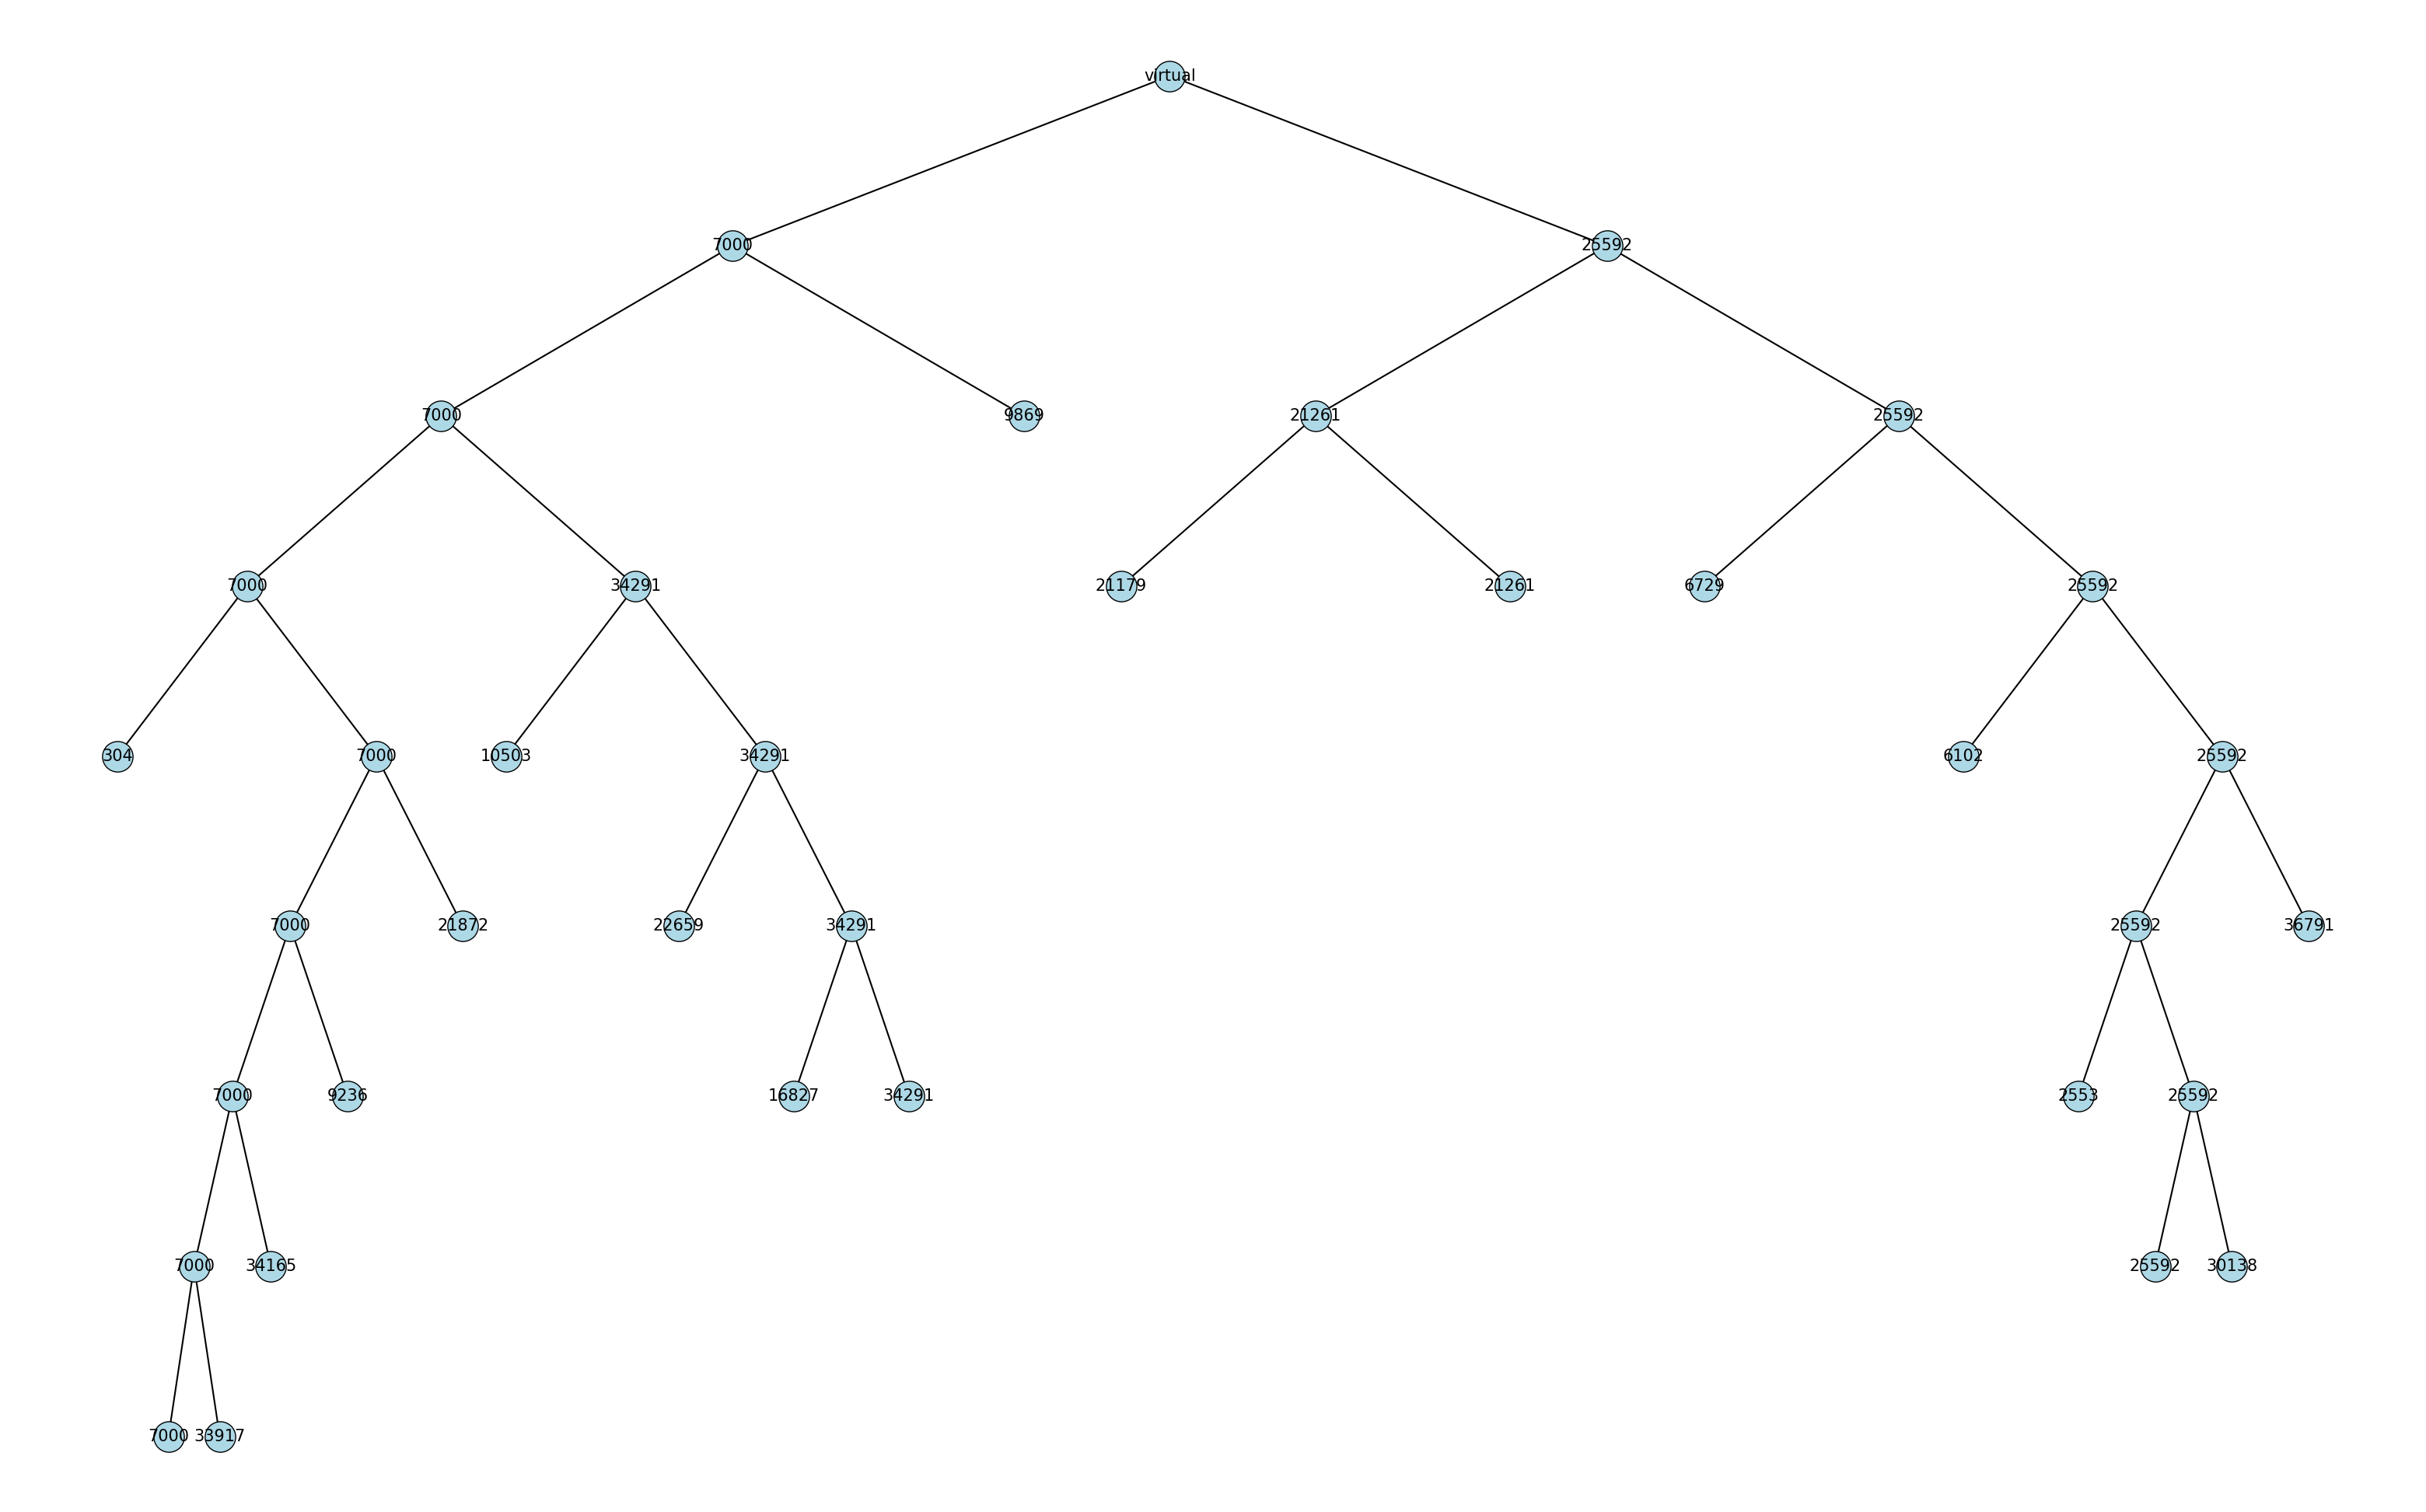

In [265]:
plotting_ftcs_tree.plot_tree(tree_sigma.hierarchy.root, tree_sigma)

## Plot the data in each node

In [267]:
# Create a directory to save the plots
output_dir = "TreeNode_XY_Plots"
os.makedirs(output_dir, exist_ok=True)

# Define colors for each true label
cols = {-1: 'lightgray', 0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'purple', 5: 'yellow', 6: 'magenta'}


alphas = {-1: 0.2, 0: 0.9, 1: 0.9, 2: 0.9, 3: 0.9, 4: 0.9, 5: 0.9, 6: 0.9}
zorders = {0: 0, 1: 1, 2: 1, 3: 1}

# Generate plots for each tree node
labels = df['labels']

for node in tree_sigma.hierarchy.traverse_top_down():
    plotting_ftcs_tree.plot_node_data(node, df, labels, output_dir, cols, alphas, zorders)

# Prune the tree

In [269]:
#postprocessing the tree - if cluster got less than star_threshold stars, remove children from tree (if they are leaves)
X = df[['x', 'y', 'z']].values

pruned_tree = tree_sigma.prune_tree(star_threshold=20, X=X, min_skew = 0.25)

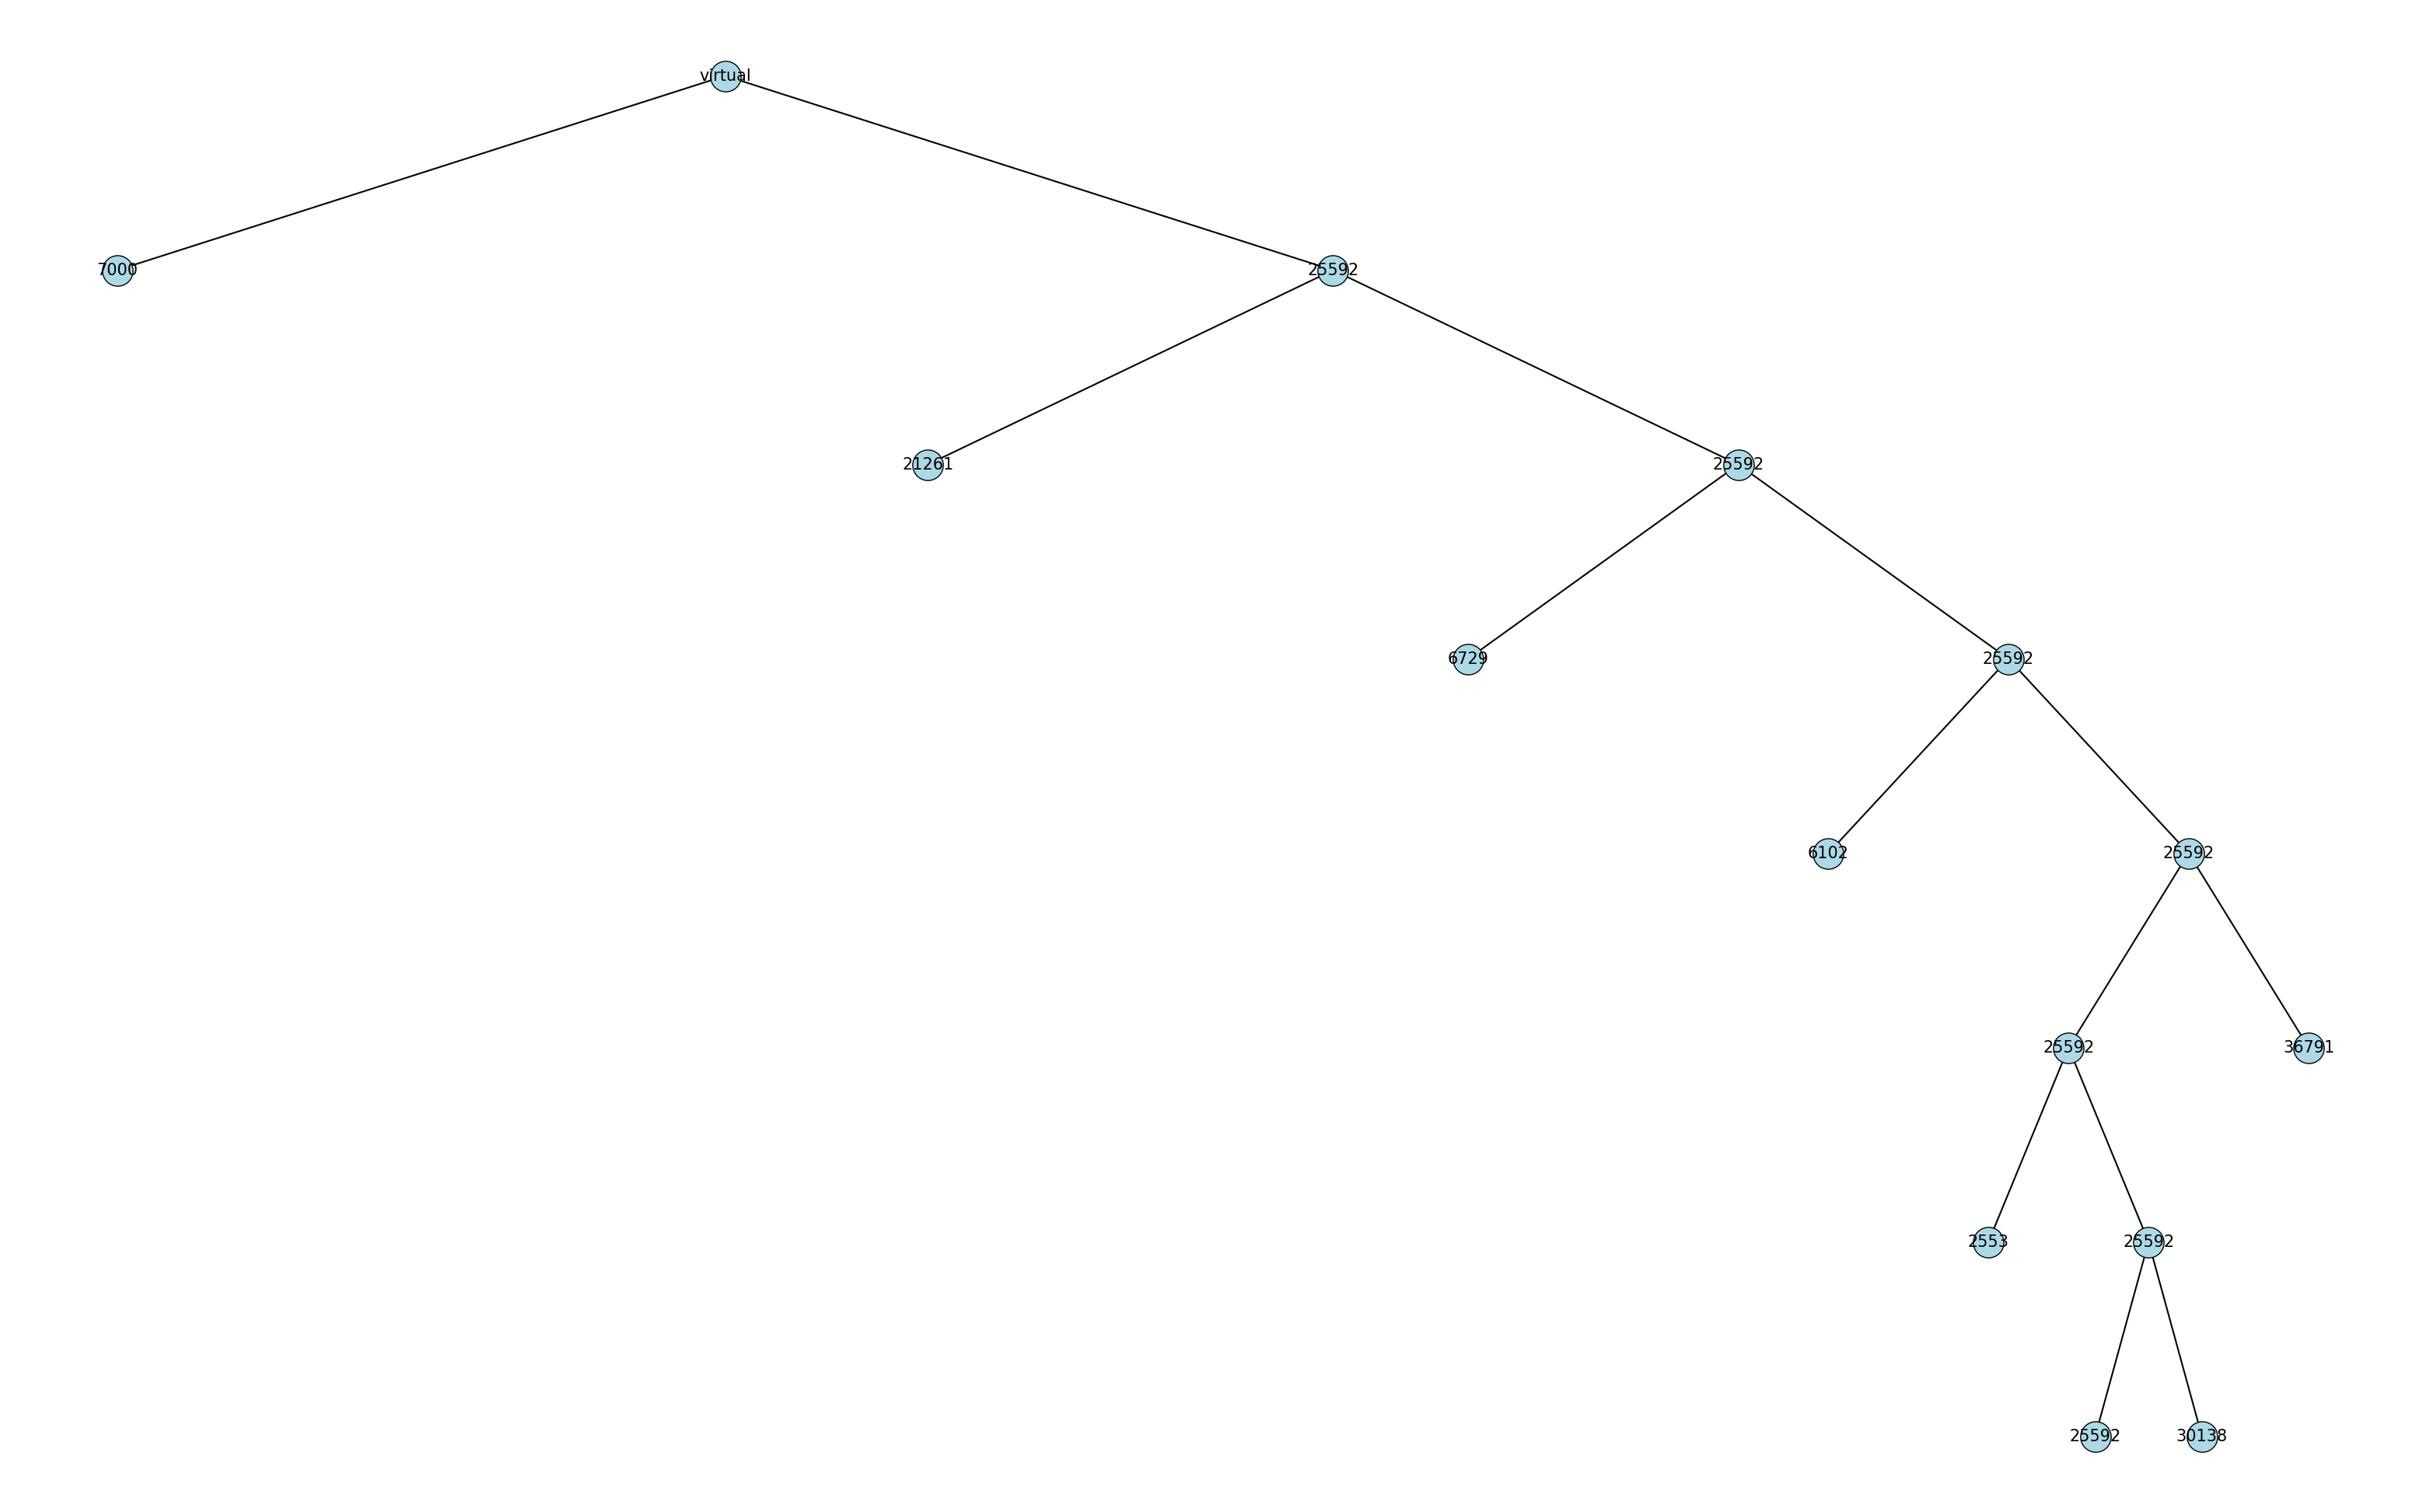

In [270]:
plotting_ftcs_tree.plot_tree(pruned_tree.hierarchy.root, tree_sigma)

In [271]:
# Generate plots for each tree node
for node in pruned_tree.hierarchy.traverse_top_down():
    plotting_ftcs_tree.plot_node_data(node, df, labels, output_dir, cols, alphas, zorders)

# Plotly 3D plot of clusters

In [273]:
# make a leaf node dataframe
df_leaves = tree_related_ftcs.extract_leaf_nodes(pruned_tree, df)
df_leaves['size'] = 10 

# 3D-Scatter-Plot with Plotly
fig = px.scatter_3d(
    df_leaves, x='x', y='y', z='z', 
    color='cluster',  # colored Cluster
    size='size',
    title='3D Scatter Plot of Leaf Nodes',
    labels={'x': 'X', 'y': 'Y', 'z': 'Z'},
    opacity=0.8,
    size_max=10
)
fig.show()
fig.write_html("3d_scatter_plot.html")

7000_0
1
21261_4
3
6729_7
5
6102_10
7
2553_15
10
25592_16
12
30138_16
13
36791_14
14


# Noise removal

In [275]:
# Remove background
df_filtered, labels_filtered, _ = shell_grid.remove_background_noise(
      df_leaves, df_leaves['cluster'], ['x', 'y', 'z', 'vt_ra', 'vt_dec'], print_info=True)


Initial dataset label distribution:
cluster
7000_0      27747
25592_16     4041
21261_4      2209
30138_16     1834
6102_10      1468
36791_14      388
6729_7        147
2553_15        46
Name: count, dtype: int64
Filtered dataset label distribution:
cluster
7000_0      1775
25592_16     258
21261_4      154
30138_16     146
6102_10      103
36791_14      26
6729_7        13
2553_15        3
Name: count, dtype: int64
Total points before filtering: 37880, after filtering: 2478
Removed 35402 background points.


In [276]:
fig = px.scatter_3d(
    df_filtered, x='x', y='y', z='z', 
    color='cluster',  # colored Cluster
    size='size',
    title='3D Scatter Plot of Leaf Nodes',
    labels={'x': 'X', 'y': 'Y', 'z': 'Z'},
    opacity=0.8,
    size_max=10
)
fig.show()

/var/folders/d6/jlfbrxvd1nvchb0xz8gj5h480000gn/T/ipykernel_40842/3530100145.py:64: UserWarning:

The figure layout has changed to tight



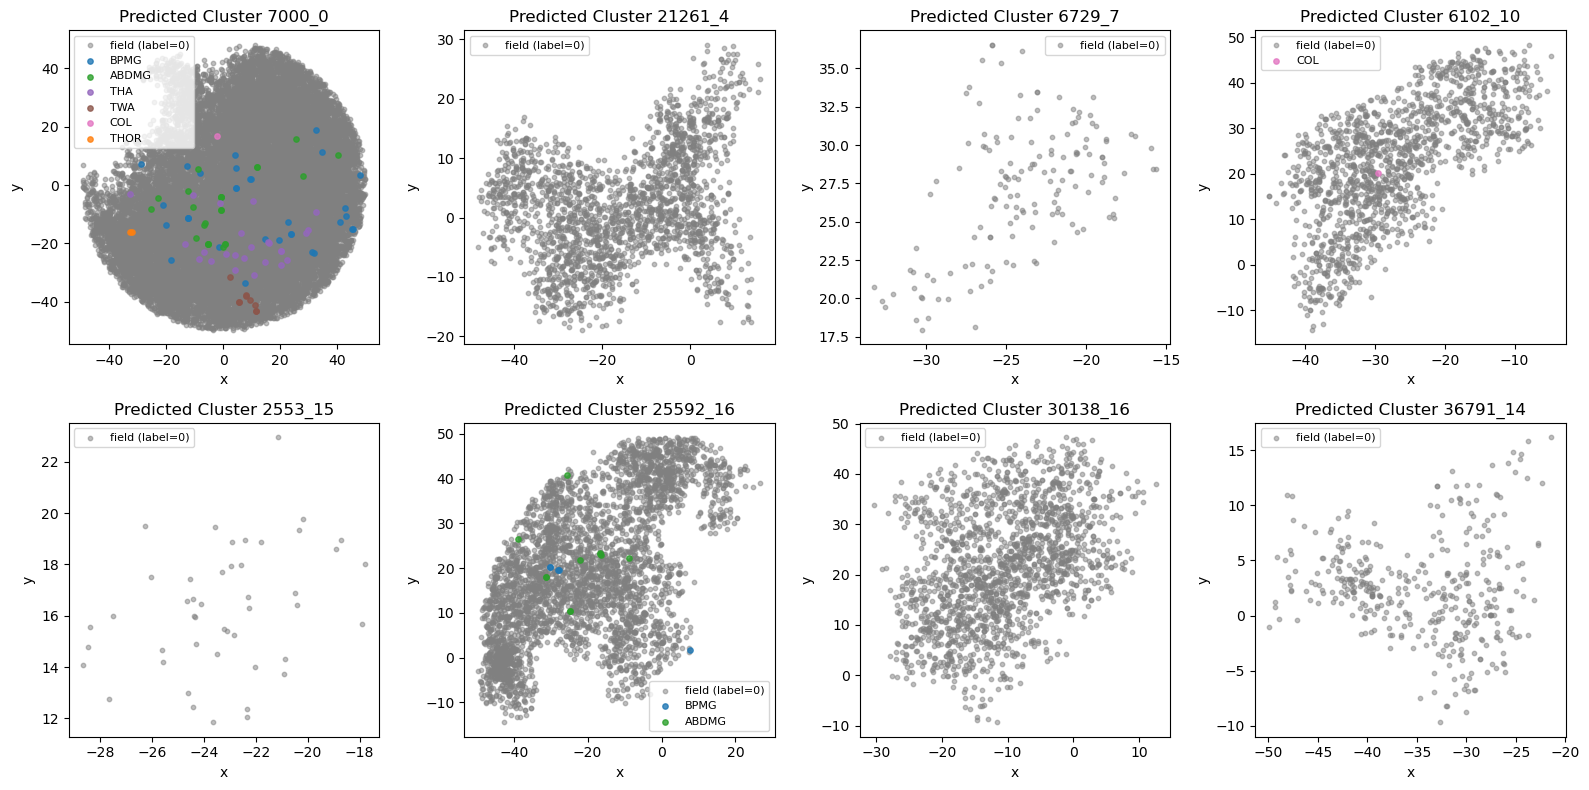

In [279]:
# Axis choice
x_axis, y_axis = 'x', 'y'

# Label names

label_names = {
    1: 'BPMG',
    2: 'CAR',
    3: 'ABDMG',
    4: 'XFOR',
    5: 'THA',
    6: 'TWA',
    7: 'COL',
    8: 'ETAC',
    9: 'THOR',
    10: 'EPSC',
    11: '118TAU',
    12: 'OCT'
}

# Colors (can be adjusted)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Get unique predicted clusters
clusters = df_leaves['cluster'].unique()
n_clusters = len(clusters)

# Set up subplot grid
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), constrained_layout=True)
axes = axes.flatten()

for idx, cluster_id in enumerate(clusters):
    ax = axes[idx]
    cluster_df = df_leaves[df_leaves['cluster'] == cluster_id]
    
    # Plot gray background for label == 0
    cluster_df_0 = cluster_df[cluster_df['labels'] == 0]
    ax.scatter(cluster_df_0[x_axis], cluster_df_0[y_axis], color='gray', alpha=0.5, s=10, label='field (label=0)')

    # Plot each known label
    for i, label in enumerate(sorted(label_names.keys())):
        label_df = cluster_df[cluster_df['labels'] == label]
        if not label_df.empty:
            ax.scatter(
                label_df[x_axis], 
                label_df[y_axis], 
                color=colors[i % len(colors)], 
                s=15, 
                alpha=0.8, 
                label=label_names[label]
            )

    ax.set_title(f'Predicted Cluster {cluster_id}')
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()